In [49]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from sympy import Piecewise, expand
from patsy import dmatrix

In [5]:
import pytensor
pytensor.config.mode='NUMBA'

In [50]:
def construct_knots(knots=None,
                    degree=3,
                    symbolic_equidistant=False,
                    num_internal_knots=None,
                    domain=(0, 1)):
    """
    Construct knot vector with boundary duplication.

    If symbolic_equidistant=True:
        knots are constructed as:
        a, a+h, a+2h, ..., b
    """

    if symbolic_equidistant:
        if num_internal_knots is None:
            raise ValueError("Provide num_internal_knots for symbolic equidistant knots.")

        a, b = domain
        h = sp.Symbol('h', positive=True)

        internal = [a + i * h for i in range(num_internal_knots + 2)]
        knots = internal

    else:
        knots = list(knots)

    # Duplicate boundary knots (open knot vector)
    left = [knots[0]] * degree
    right = [knots[-1]] * degree

    full_knots = left + knots + right

    return full_knots


def bspline_basis(knots, degree, x, simplify=False):
    """
    Returns list of basis functions for all degrees up to `degree`.

    Output:
        basis[d][i] = i-th basis function of degree d
    """

    n = len(knots) - 1

    # Store basis functions by degree
    basis = []

    # --- Degree 0 ---
    B0 = []
    for i in range(n):
        if knots[i] == knots[i+1]:
            B0.append(sp.Integer(0))
        elif knots[i+1] == knots[i+2]:
            B0.append(
                sp.Piecewise(
                    (1, (x >= knots[i]) & (x <= knots[i+1])),
                    (0, True)
                )
            )
        else:
            B0.append(
                sp.Piecewise(
                    (1, (x >= knots[i]) & (x < knots[i+1])),
                    (0, True)
                )
            )
    basis.append(B0)

    # --- Higher degrees ---
    for d in range(1, degree + 1):
        Bd = []
        prev = basis[d - 1]

        for i in range(len(prev) - 1):

            denom1 = knots[i + d] - knots[i]
            denom2 = knots[i + d + 1] - knots[i + 1]

            term1 = 0
            term2 = 0

            if denom1 != 0:
                term1 = ((x - knots[i]) / denom1) * prev[i]

            if denom2 != 0:
                term2 = ((knots[i + d + 1] - x) / denom2) * prev[i + 1]

            Bd.append(sp.simplify(term1 + term2) if simplify else term1 + term2)

        basis.append(Bd)

    return basis


def generate_spline_basis(knots=None,
                           degree=3,
                           symbolic_equidistant=False,
                           num_internal_knots=None,
                           domain=(0, 1)):
    """
    Main function combining everything.
    """

    x = sp.Symbol('x', real=True, nonnegative=True)

    full_knots = construct_knots(
        knots=knots,
        degree=degree,
        symbolic_equidistant=symbolic_equidistant,
        num_internal_knots=num_internal_knots,
        domain=domain
    )

    basis = bspline_basis(full_knots, degree, x)

    basis_symbolic = None
    if symbolic_equidistant:
        basis_symbolic = basis
        h_val = (domain[1] - domain[0]) / (num_internal_knots + 1)
        h = sp.Symbol('h', positive=True, real=True)
        basis = [
            [b.subs(h, h_val) if isinstance(b, sp.Basic) else b for b in degree_basis]
            for degree_basis in basis
        ]
    return {
        "x": x,
        "knots": [k.subs(h, h_val) for k in full_knots],
        "knots_symbolic": full_knots,
        "basis": basis,
        "basis_symbolic": basis_symbolic
    }

In [51]:
def bspline_basis_full_knots(full_knots, degree, x, simplify=False):
    """
    Returns list of basis functions for all degrees up to `degree`.

    Output:
        basis[d][i] = i-th basis function of degree d
    """

    n = len(full_knots)

    # Store basis functions by degree
    basis = []

    # --- Degree 0 ---
    B0 = []
    for i in range(n-1):
        if full_knots[i] == full_knots[i+1]:
            print('g')
            B0.append(sp.Integer(0))
        else:
            B0.append(
                sp.Piecewise(
                    (1, (x >= full_knots[i]) & (x < full_knots[i+1])),
                    (0, True)
                )
            )
    basis.append(B0)

    # --- Higher degrees ---
    for d in range(1, degree + 1):
        Bd = []
        prev = basis[d - 1]

        for i in range(len(prev) - 1):

            denom1 = full_knots[i + d] - full_knots[i]
            denom2 = full_knots[i + d + 1] - full_knots[i + 1]

            term1 = 0
            term2 = 0

            if denom1 != 0:
                term1 = ((x - full_knots[i]) / denom1) * prev[i]

            if denom2 != 0:
                term2 = ((full_knots[i + d + 1] - x) / denom2) * prev[i + 1]

            Bd.append(sp.simplify(term1 + term2) if simplify else term1 + term2)

        basis.append(Bd)

    return basis


def generate_spline_basis_full_knots(full_knots,
                           degree=3,
                           subs_dict=None):
    """
    Main function combining everything.
    """

    x = sp.Symbol('x', real=True)
    basis_symbolic = bspline_basis_full_knots(full_knots, degree, x)

    if subs_dict is not None:
        basis = [
            [b.subs(subs_dict) if isinstance(b, sp.Basic) else b for b in degree_basis]
            for degree_basis in basis_symbolic
        ]
        knots_subs = [k.subs(subs_dict) for k in full_knots]
    else:
        basis = basis_symbolic
        knots_subs = full_knots

    return {
        "x": x,
        "knots": knots_subs,
        "knots_symbolic": full_knots,
        "basis": basis,
        "basis_symbolic": basis_symbolic
    }

In [52]:
# repeated knots
degree=3
num_internal_knots=9
domain=(0,1)
B = generate_spline_basis(knots=None,
                           degree=degree,
                           symbolic_equidistant=True,
                           num_internal_knots=num_internal_knots,
                           domain=domain)

number of basis functions: 15, number of nonzero basis functions: 11


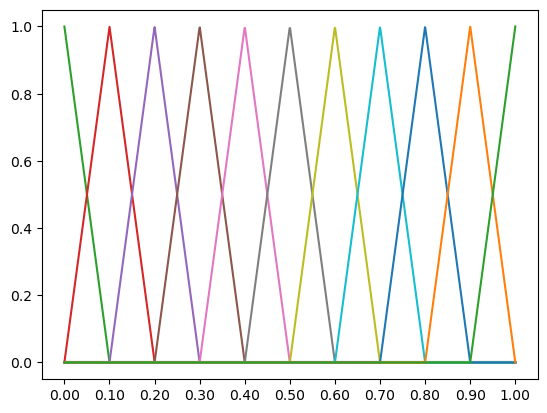

In [53]:
degree = 3
plot_degree=1
domain_plot = np.linspace(0, 1, 1000)
x = B['x']
B_plot = np.zeros((num_internal_knots + degree + 1, len(domain_plot))).T
for i in range(num_internal_knots + degree + 1):
    B_i = B['basis'][plot_degree][i]
    B_i_f = sp.lambdify(x, B_i, "numpy")
    B_plot[:, i] = B_i_f(domain_plot)
# B_plot[-1, -1] = 1 - np.sum(B_plot[-1, :-1])

print(f'number of basis functions: {len(B["basis"][plot_degree])}, number of nonzero basis functions: {np.sum(np.sum(B_plot, axis=0) > 0)}')
if plot_degree == 0:
    plt.step(domain_plot, B_plot, where='mid')
else:
    plt.plot(domain_plot, B_plot[:, :])
ticks = np.unique(np.array(B['knots'], dtype=float))
plt.xticks(ticks, labels=[f"{t:.2f}" for t in ticks])
plt.show()

In [54]:
B_patsy = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=True)-1",
                        {"s": domain_plot, "knots": np.unique(B['knots'])[1:-1], "degree":plot_degree})
B_plot_nonzero = B_plot[:, np.where(np.sum(np.abs(B_plot), axis=0) > 0)].squeeze()
np.all(np.isclose(B_plot_nonzero, B_patsy, atol=1e-10))

array(True)

In [55]:
# equispaced
degree=3
num_internal_knots=9
domain=(0,1)
knots = np.linspace(domain[0], domain[1], num_internal_knots + 2)
h_val = (domain[1] - domain[0]) / (num_internal_knots + 1)
if degree > 0:
    left_knots = np.linspace(domain[0] - (degree) * h_val, domain[0], degree+1)[:-1]
    right_knots = np.linspace(domain[1], domain[1] + (degree) * h_val, degree+1)[1:]
    knots = np.concatenate([left_knots, knots, right_knots])
print(knots)
B = generate_spline_basis_full_knots(full_knots=knots,
                           degree=degree,
                           subs_dict=None)

[-0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.
  1.1  1.2  1.3]


In [56]:
# equispaced
degree=3
num_internal_knots=9
domain=(0,1)
h = sp.Symbol('h', positive=True, real=True)
knots = [domain[0] + i * h for i in range(num_internal_knots + 2)]
# knots = np.linspace(domain[0], domain[1], num_internal_knots + 2)
h_val = (domain[1] - domain[0]) / (num_internal_knots + 1)
if degree > 0:
    left_knots = [domain[0] - (degree - i) * h for i in range(degree)]
    right_knots = [domain[1] + (i + 1) * h for i in range(degree)]
    # left_knots = np.linspace(domain[0] - (degree) * h_val, domain[0], degree+1)[:-1]
    # right_knots = np.linspace(domain[1], domain[1] + (degree) * h_val, degree+1)[1:]
    knots = np.concatenate([left_knots, knots, right_knots])
print(knots)
B = generate_spline_basis_full_knots(full_knots=knots,
                           degree=degree,
                           subs_dict={h: h_val})

[-3*h -2*h -h 0 h 2*h 3*h 4*h 5*h 6*h 7*h 8*h 9*h 10*h h + 1 2*h + 1
 3*h + 1]


number of basis functions: 13, number of nonzero basis functions: 13


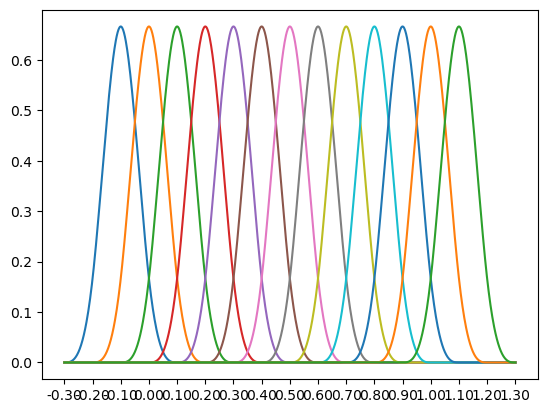

In [57]:
plot_degree=3
knots = np.array(B['knots'], dtype=float)
domain_plot = np.linspace(knots[0], knots[-1], 1000)
x = B['x']
B_plot = np.zeros((len(B['basis'][plot_degree]), len(domain_plot))).T
for i in range(len(B['basis'][plot_degree])):
    B_i = B['basis'][plot_degree][i]
    B_i_f = sp.lambdify(x, B_i, "numpy")
    B_plot[:, i] = B_i_f(domain_plot)

print(f'number of basis functions: {len(B["basis"][plot_degree])}, number of nonzero basis functions: {np.sum(np.sum(B_plot, axis=0) > 0)}')
if plot_degree == 0:
    plt.step(domain_plot, B_plot, where='mid')
else:
    plt.plot(domain_plot, B_plot[:, :])
ticks = np.unique(np.array(B['knots'], dtype=float))
plt.xticks(ticks, labels=[f"{t:.2f}" for t in ticks])
plt.show()

---

# Equispaced Non Repeated

In [115]:
f_degree = 3
h = sp.Symbol('h', positive=True, real=True)
x = sp.Symbol('x', nonnegative=True, real=True)
n = len(B['basis_symbolic'][degree])
w = sp.symbols(f'w0:{n}', real=True)
f = sum(w[i] * B['basis_symbolic'][degree][i] for i in range(n))

In [116]:
n = len(B['knots'])
t_3 = B['knots_symbolic'][3]
t_n_3 = B['knots_symbolic'][-4]
t_3_sub = float(t_3.subs(h, h_val))
t_n_3_sub = float(t_n_3.subs(h, h_val))
print(f't_3: {t_3}, t_n_3: {t_n_3}')

t_3: 0, t_n_3: 10*h


In [117]:
d2w = [w[j] - 2*w[j-1] + w[j-2] for j in range(2, len(w))]
d2w = np.concatenate(([0, 0], d2w))
print(len(d2w))
display(d2w)

h = sp.Symbol('h', positive=True, real=True)
f_d1 = sp.diff(f, B['x'])
f_d2 = sp.diff(f_d1, B['x'])

f_dd = (1 / h**2) * sum(d2w[j] * B['basis_symbolic'][degree-2][j] for j in range(2, 13))

13


array([0, 0, w0 - 2*w1 + w2, w1 - 2*w2 + w3, w2 - 2*w3 + w4,
       w3 - 2*w4 + w5, w4 - 2*w5 + w6, w5 - 2*w6 + w7, w6 - 2*w7 + w8,
       w7 - 2*w8 + w9, w10 + w8 - 2*w9, -2*w10 + w11 + w9,
       w10 - 2*w11 + w12], dtype=object)

In [118]:
len(B['knots']), len(w), len(B['basis'][degree]), len(d2w)

(17, 13, 13, 13)

In [119]:
w_val = np.zeros(len(w))
w_val[0] = 1
w_val = np.random.rand(len(w))
print(w_val)

subs_dict = {w[i]: w_val[i] for i in range(len(w))}

f_sub_w = f.subs(subs_dict)
f_d2_sub_w = f_d2.subs(subs_dict)
f_dd_sub_w = f_dd.subs(subs_dict)

f_sub = f_sub_w.subs(h, h_val)
f_d2_sub = f_d2_sub_w.subs(h, h_val)
f_dd_sub = f_dd_sub_w.subs(h, h_val)

[0.34738251 0.11475481 0.38825453 0.86014813 0.40846903 0.77885365
 0.28483186 0.15027097 0.30296312 0.8414196  0.94594309 0.18529851
 0.03969682]


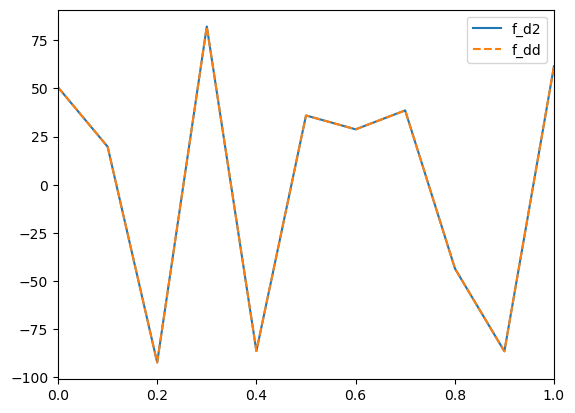

In [120]:
domain_plot = np.linspace(t_3_sub, t_n_3_sub, 10000)
f_sub_plot = sp.lambdify(x, f_sub, "numpy")
f_d2_sub_plot = sp.lambdify(x, f_d2_sub, "numpy")
f_dd_sub_plot = sp.lambdify(x, f_dd_sub, "numpy")

# plt.plot(domain_plot, f_sub_plot(domain_plot))
plt.plot(domain_plot, f_d2_sub_plot(domain_plot), label='f_d2')
plt.plot(domain_plot, f_dd_sub_plot(domain_plot), label='f_dd', linestyle='dashed')
plt.legend()
plt.xlim(t_3_sub, t_n_3_sub)
plt.show()

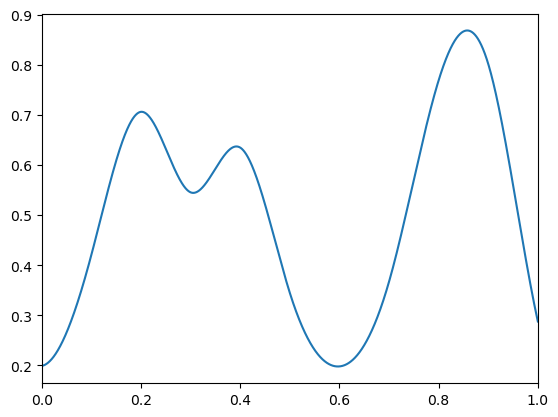

In [121]:
plt.plot(domain_plot, f_sub_plot(domain_plot))
plt.xlim(t_3_sub, t_n_3_sub)

plt.show()

In [122]:
int_f_dd_sq = (1/3/h**3)*(d2w[2]**2 + 2*sum(d2w[j]**2 for j in range(3, len(d2w)-1)) + d2w[-1]**2 + sum(d2w[j]*d2w[j+1] for j in range(2, len(d2w)-1)))

In [130]:
d2Vw = np.array([v.subs(subs_dict).subs(h, h_val) if isinstance(v, sp.Basic) else v for v in d2w])
d2Vw = np.array([w_val[j] - 2*w_val[j-1] + w_val[j-2] for j in range(2, len(w_val))])
d2Vw = w_val[2:] - 2*w_val[1:-1] + w_val[:-2]
(1/(3*h_val**3))*(d2Vw[0]**2 + 2*np.sum(d2Vw[1:-1]**2) + d2Vw[-1]**2 + np.sum(d2Vw[0:-1]*d2Vw[1:]))

1962.1430147698616

In [131]:
int_f_dd_sq_sub = int_f_dd_sq.subs(subs_dict).subs(h, h_val)
print(f'int_f_dd_sq_sub: {int_f_dd_sq_sub}')

int_f_dd_sq_sub: 1962.14301476986


In [86]:
np.mean(f_d2_sub_plot(domain_plot)**2)

3107.8361361844422

In [83]:
np.trapz(f_d2_sub_plot(domain_plot)**2, domain_plot)

3107.1066691188494

## Expression is correct
Riemann/Trapezoidal approximation to integral matches formula value

---

In [1]:
from spline_utils import *

In [8]:
domain = (0, 1)
degree = 3
num_knots = 5
x_vals = np.linspace(domain[0], domain[1], 100)
B_plot, x, fk, k = eval_spline_basis_equispaced_numeric(degree, domain[0], domain[1], num_knots, x_vals).values()

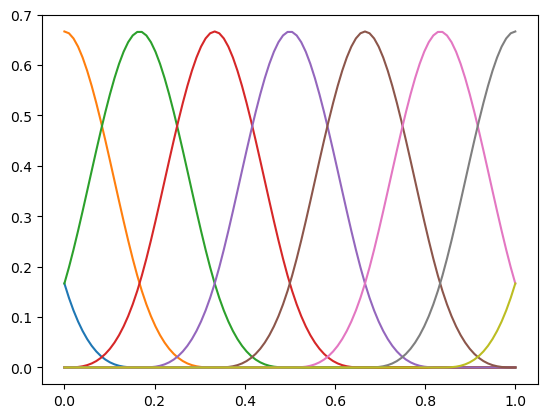

In [10]:
plt.plot(x_vals, B_plot[:, :])
plt.xticks()
plt.show()

In [ ]:
x = sp.symbols('x', real=True)
int_f_d2_sq = sp.integrate(f_d2_sub**2, (x, t_3, t_n_3))

---

In [88]:
f_dd_sub.simplify()

Piecewise((1000.0*x + 100.0, (x >= -0.1) & (x < 0)), (100.0 - 1000.0*x, (x < 0.1) & (x >= 0)), (0, True))

In [89]:
f_d2_sub.simplify()

Piecewise((400.0 - 4.54747350886464e-13*x, (x < -0.2) & (x >= 0)), (999.999999999999*x + 300.0, (x >= -0.3) & (x < -0.2)), (-(4000.0*x + 400.0), (x < -0.1) & (x >= 0)), (100.0 - 1000.0*x, (x < 0.1) & (x >= 0)), (3000.0*x + 100.0, (x >= -0.1) & (x < 0)), (-(3000.0*x + 500.0), (x >= -0.2) & (x < -0.1)), (0, True))

In [ ]:
h_val = (domain[1] - domain[0]) / (num_internal_knots + 1)

f_sub = f.subs(h, h_val)
f_d2_sub = f_d2.subs(h, h_val)
f_dd_sub = f_dd.subs(h, h_val)

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [124]:
f_sub

1.0*Piecewise((1000.0*(0.1 - x)**3, x < 0.1), (0, True))

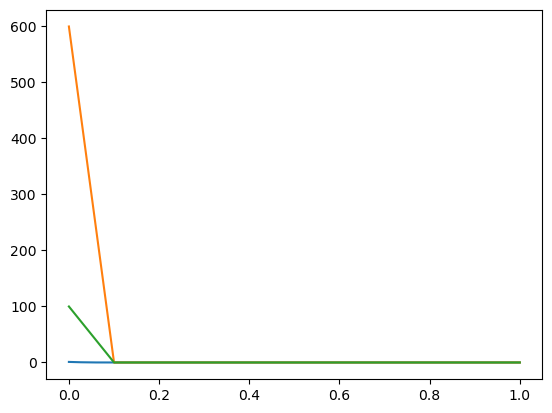

In [119]:
f_sub_plot = sp.lambdify(x, f_sub, "numpy")
f_d2_sub_plot = sp.lambdify(x, f_d2_sub, "numpy")
f_dd_sub_plot = sp.lambdify(x, f_dd_sub, "numpy")

plt.plot(domain_plot, f_sub_plot(domain_plot))
plt.plot(domain_plot, f_d2_sub_plot(domain_plot))
plt.plot(domain_plot, f_dd_sub_plot(domain_plot))
plt.show()


/tmp/ipykernel_1677441/34936995.py:1: RuntimeWarning: invalid value encountered in divide
  ratio = f_d2_sub_plot(domain_plot) / f_dd_sub_plot(domain_plot)


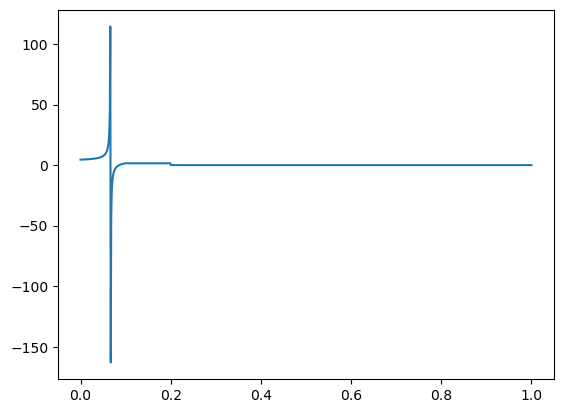

In [99]:
ratio = f_d2_sub_plot(domain_plot) / f_dd_sub_plot(domain_plot)
ratio[np.isnan(ratio)]=0.0
plt.plot(domain_plot, ratio)

In [89]:
f_d2_sub

1.0*Piecewise((10500.0*x - 900.0, x < 0.1), (300.0 - 1500.0*x, x < 0.2), (0, True))

In [54]:
expr = (f_dd - f_d2).simplify()

In [60]:
expr.args[0][1]

(h > x) & (x >= 5*h) & (x <= 6*h)

In [61]:
f_expanded = Piecewise(*[
    (expand(ec[0]), ec[1]) for ec in expr.args
])

In [62]:
f_expanded

Piecewise((w1/h**2 + 25*w10/h**2 - 2*w2/h**2 + 11*w3/(2*h**2) - 9*w4/h**2 + 9*w5/(2*h**2) + 18*w6/h**2 - 78*w7/h**2 + 127*w8/h**2 - 92*w9/h**2 - 2*w1*x/h**3 - 10*w10*x/h**3 + 6*w2*x/h**3 - 9*w3*x/h**3 + 8*w4*x/h**3 - 3*w5*x/h**3 - 6*w6*x/h**3 + 28*w7*x/h**3 - 48*w8*x/h**3 + 36*w9*x/h**3 + w1*x**2/h**4 + w10*x**2/h**4 - 7*w2*x**2/(2*h**4) + 5*w3*x**2/h**4 - 7*w4*x**2/(2*h**4) + w5*x**2/h**4 + w6*x**2/(2*h**4) - 5*w7*x**2/(2*h**4) + 9*w8*x**2/(2*h**4) - 7*w9*x**2/(2*h**4), (h > x) & (x >= 5*h) & (x <= 6*h)), (w1/h**2 - 2*w2/h**2 + 11*w3/(2*h**2) - w4/h**2 - 23*w5/h**2 + 71*w6/(2*h**2) - 41*w7/(2*h**2) + 9*w8/(2*h**2) - 2*w1*x/h**3 + 6*w2*x/h**3 - 9*w3*x/h**3 + 4*w4*x/h**3 + 12*w5*x/h**3 - 21*w6*x/h**3 + 13*w7*x/h**3 - 3*w8*x/h**3 + w1*x**2/h**4 - 7*w2*x**2/(2*h**4) + 5*w3*x**2/h**4 - 3*w4*x**2/h**4 - w5*x**2/h**4 + 3*w6*x**2/h**4 - 2*w7*x**2/h**4 + w8*x**2/(2*h**4), (h > x) & (x >= 3*h)), (w1/h**2 - 2*w2/h**2 + 11*w3/(2*h**2) - 29*w4/(2*h**2) + 35*w5/(2*h**2) - 19*w6/(2*h**2) + 2*w7/h**2

In [64]:
f_expanded_num = f_expanded.subs(h, h_val).subs(subs_dict)

In [67]:
f_expanded_num_f = sp.lambdify(x, f_expanded_num, "numpy")

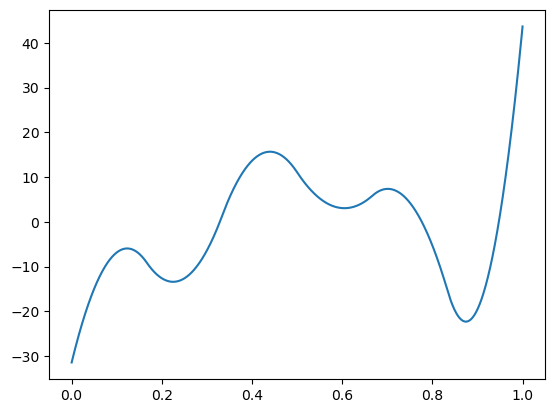

In [71]:
plt.plot(domain_plot, f_expanded_num_f(domain_plot))

In [37]:
degree = 3
plot_degree=3
domain_plot = np.linspace(0, 1, 1000)
x = B['x']
f_ddd2_diff_plot = np.zeros(len(domain_plot))
h_val = (domain[1] - domain[0]) / (num_internal_knots + 1)
w_val = np.random.rand(n)
print(w_val)
subs_dict = {w[i]: w_val[i] for i in range(n)}
f_ddd2_diff = sp.lambdify(x, (f_dd - f_d2).subs(h, h_val).subs(subs_dict), "numpy")


[0.9542528  0.01850723 0.84381927 0.79648571 0.83426509 0.28023342
 0.38765214 0.44915112 0.87996677 0.09354577 0.51971629 0.15566039]


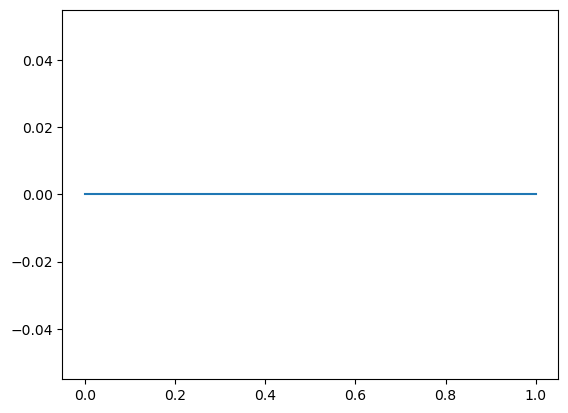

In [38]:
plt.plot(domain_plot, f_ddd2_diff_plot)

In [18]:
f_ddd2_diff_plot = f_ddd2_diff(domain_plot)
#plt.plot(domain_plot, f_ddd2_diff_plot)